In [2]:
# ============================================================
# ECG Arrhythmia Detection with MC Dropout Uncertainty
# Full Updated Version
# ============================================================

!pip install -q wfdb

import os
import random
import copy
import numpy as np
import matplotlib.pyplot as plt

import wfdb
from scipy.signal import butter, filtfilt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


In [3]:
# ============================================================
# 1. Setup
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [4]:
# ============================================================
# 2. Download MIT-BIH
# ============================================================

DATA_DIR = "/content/mitdb"

if not os.path.isdir(DATA_DIR) or len([f for f in os.listdir(DATA_DIR) if f.endswith(".hea")]) < 40:
    print("Downloading MIT-BIH Arrhythmia Database...")
    wfdb.dl_database("mitdb", dl_dir=DATA_DIR)
else:
    print("MIT-BIH already downloaded.")

records = sorted([int(f[:-4]) for f in os.listdir(DATA_DIR) if f.endswith(".hea")])
print("Available records:", records)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [6]:
# ============================================================
# 3. Configuration
# ============================================================

AAMI_CLASSES = ["N", "S", "V", "F", "Q"]
VAL_RECORDS = [209, 223, 106]
TRAIN_RECORDS = [r for r in DS1_ALL if r not in VAL_RECORDS]
AAMI_MAP = {
    "N": "N", "L": "N", "R": "N", "e": "N", "j": "N",
    "A": "S", "a": "S", "J": "S", "S": "S",
    "V": "V", "E": "V",
    "F": "F",
    "/": "Q", "f": "Q", "Q": "Q",
}

CLS_IDX = {c: i for i, c in enumerate(AAMI_CLASSES)}

# De Chazal-style inter-patient split
DS1_ALL = [
    101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122,
    124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230
]

DS2 = [
    100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210,
    212, 213, 214, 219, 221, 222, 228, 231, 232, 233, 234
]

assert not set(TRAIN_RECORDS) & set(VAL_RECORDS)
assert not set(TRAIN_RECORDS) & set(DS2)
assert not set(VAL_RECORDS) & set(DS2)

print("Train records:", TRAIN_RECORDS)
print("Val records  :", VAL_RECORDS)
print("Test records :", DS2)
print("Strict patient-independent split: PASSED")

FS = 360
#VAL_RECORDS = [209, 223, 106]
#TRAIN_RECORDS = [r for r in DS1_ALL if r not in VAL_RECORDS]
# Beat window
WIN_BEFORE = 200
WIN_AFTER = 140
WINDOW = WIN_BEFORE + WIN_AFTER

# RR features
N_RR_FEATS = 5

# Model
CNN_DROP = 0.10
LSTM_DROP = 0.25
HEAD_DROP = 0.30
LSTM_HIDDEN = 64

# Training
BATCH_SIZE = 256
EPOCHS = 80
PATIENCE = 12
LR = 5e-4
WEIGHT_DECAY = 1e-4

# Uncertainty
MC_SAMPLES = 50
N_ECE_BINS = 15

Train records: [101, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 215, 220, 230]
Val records  : [209, 223, 106]
Test records : [100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213, 214, 219, 221, 222, 228, 231, 232, 233, 234]
Strict patient-independent split: PASSED


In [7]:
assert not set(TRAIN_RECORDS) & set(VAL_RECORDS)
assert not set(TRAIN_RECORDS) & set(DS2)
assert not set(VAL_RECORDS) & set(DS2)

print("VAL_RECORDS:", VAL_RECORDS)
print("TRAIN_RECORDS:", TRAIN_RECORDS)

VAL_RECORDS: [209, 223, 106]
TRAIN_RECORDS: [101, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 215, 220, 230]


In [8]:
# ============================================================
# 4. Preprocessing and Beat Segmentation
# ============================================================

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=FS, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")

    try:
        out = filtfilt(b, a, signal).astype(np.float32)
        if np.isnan(out).any() or np.isinf(out).any():
            return signal.astype(np.float32)
        return out
    except Exception:
        return signal.astype(np.float32)


def robust_normalize_beat(beat):
    med = np.median(beat)
    iqr = np.percentile(beat, 75) - np.percentile(beat, 25)
    beat = (beat - med) / (iqr + 1e-6)
    beat = np.clip(beat, -6, 6)
    return beat.astype(np.float32)


def segment_record(record_num, data_dir=DATA_DIR):
    rec = wfdb.rdrecord(f"{data_dir}/{record_num}")
    ann = wfdb.rdann(f"{data_dir}/{record_num}", "atr")

    # Prefer MLII lead
    lead = 0
    for j, name in enumerate(rec.sig_name):
        name_up = name.upper()
        if "MLII" in name_up or name_up in ["II", "ML2"]:
            lead = j
            break

    raw = rec.p_signal[:, lead].astype(np.float32)
    raw = np.nan_to_num(raw, nan=0.0, posinf=0.0, neginf=0.0)

    sig = bandpass_filter(raw)

    r_samples = []
    labels = []
    beats = []

    for samp, sym in zip(ann.sample, ann.symbol):
        cls = AAMI_MAP.get(sym)

        if cls is None:
            continue

        s = int(samp)

        if s - WIN_BEFORE < 0 or s + WIN_AFTER > len(sig):
            continue

        beat = sig[s - WIN_BEFORE : s + WIN_AFTER]

        if np.isnan(beat).any() or np.isinf(beat).any():
            continue

        # Remove flat or extreme artifact beats
        if beat.std() < 0.03:
            continue

        beat = robust_normalize_beat(beat)

        r_samples.append(s)
        labels.append(CLS_IDX[cls])
        beats.append(beat)

    if len(r_samples) < 2:
        return (
            np.empty((0, WINDOW), dtype=np.float32),
            np.empty((0, N_RR_FEATS), dtype=np.float32),
            np.empty((0,), dtype=np.int64)
        )

    # RR interval features
    t = np.array(r_samples, dtype=np.float64) / FS
    rr = np.diff(t)
    n = len(t)

    rr_pre = np.empty(n, dtype=np.float64)
    rr_post = np.empty(n, dtype=np.float64)

    rr_pre[1:] = rr
    rr_pre[0] = rr[0]

    rr_post[:-1] = rr
    rr_post[-1] = rr[-1]

    rr_local = np.array([
        rr_pre[max(0, i - 7): i + 1].mean()
        for i in range(n)
    ], dtype=np.float64)

    rr_feats = np.stack([
        rr_pre,
        rr_post,
        rr_local,
        rr_pre / (rr_local + 1e-6),
        rr_post / (rr_local + 1e-6)
    ], axis=1).astype(np.float32)

    return (
        np.stack(beats).astype(np.float32),
        rr_feats,
        np.array(labels, dtype=np.int64)
    )


def build_dataset(record_list, tag):
    Xs, Rs, ys = [], [], []

    print(f"\n--- {tag} ---")

    for r in record_list:
        try:
            X, R, y = segment_record(r)
        except Exception as e:
            print(f"{r}: skipped because {e}")
            continue

        if len(y) > 0:
            Xs.append(X)
            Rs.append(R)
            ys.append(y)

        print(f"{r}: {len(y):5d} beats | counts {np.bincount(y, minlength=5)}")

    return np.concatenate(Xs), np.concatenate(Rs), np.concatenate(ys)


Xtr, Rtr, ytr = build_dataset(TRAIN_RECORDS, "TRAIN")
Xvl, Rvl, yvl = build_dataset(VAL_RECORDS, "VALIDATION")
Xte, Rte, yte = build_dataset(DS2, "TEST")


def print_class_counts(name, y):
    counts = np.bincount(y, minlength=5)
    print(f"\n{name} class counts:")
    for cls, c in zip(AAMI_CLASSES, counts):
        print(f"{cls}: {c}")


print_class_counts("Train", ytr)
print_class_counts("Validation", yvl)
print_class_counts("Test", yte)


--- TRAIN ---
101:  1864 beats | counts [1859    3    0    0    2]
108:  1762 beats | counts [1739    4   17    2    0]
109:  2530 beats | counts [2490    0   38    2    0]
112:  2537 beats | counts [2535    2    0    0    0]
114:  1879 beats | counts [1820   12   43    4    0]
115:  1951 beats | counts [1951    0    0    0    0]
116:  2404 beats | counts [2294    1  109    0    0]
118:  2277 beats | counts [2165   96   16    0    0]
119:  1987 beats | counts [1543    0  444    0    0]
122:  2474 beats | counts [2474    0    0    0    0]
124:  1618 beats | counts [1535   31   47    5    0]
201:  1962 beats | counts [1634  128  198    2    0]
203:  2979 beats | counts [2528    2  444    1    4]
205:  2656 beats | counts [2571    3   71   11    0]
207:  1859 beats | counts [1542  107  210    0    0]
208:  2952 beats | counts [1584    2  992  372    2]
215:  3361 beats | counts [3193    3  164    1    0]
220:  2046 beats | counts [1952   94    0    0    0]
230:  2255 beats | counts [2254

In [10]:
# Create the training, validation, and test datasets,
# then check how many samples belong to each class in every split.
Xtr, Rtr, ytr = build_dataset(TRAIN_RECORDS, "TRAIN")
Xvl, Rvl, yvl = build_dataset(VAL_RECORDS, "VALIDATION")
Xte, Rte, yte = build_dataset(DS2, "TEST")

print_class_counts("Train", ytr)
print_class_counts("Validation", yvl)
print_class_counts("Test", yte)


--- TRAIN ---
101:  1864 beats | counts [1859    3    0    0    2]
108:  1762 beats | counts [1739    4   17    2    0]
109:  2530 beats | counts [2490    0   38    2    0]
112:  2537 beats | counts [2535    2    0    0    0]
114:  1879 beats | counts [1820   12   43    4    0]
115:  1951 beats | counts [1951    0    0    0    0]
116:  2404 beats | counts [2294    1  109    0    0]
118:  2277 beats | counts [2165   96   16    0    0]
119:  1987 beats | counts [1543    0  444    0    0]
122:  2474 beats | counts [2474    0    0    0    0]
124:  1618 beats | counts [1535   31   47    5    0]
201:  1962 beats | counts [1634  128  198    2    0]
203:  2979 beats | counts [2528    2  444    1    4]
205:  2656 beats | counts [2571    3   71   11    0]
207:  1859 beats | counts [1542  107  210    0    0]
208:  2952 beats | counts [1584    2  992  372    2]
215:  3361 beats | counts [3193    3  164    1    0]
220:  2046 beats | counts [1952   94    0    0    0]
230:  2255 beats | counts [2254

In [11]:
# ============================================================
# 5. RR Feature Normalization
# Train statistics only: avoids leakage
# ============================================================

rr_mu = Rtr.mean(axis=0, keepdims=True)
rr_sd = Rtr.std(axis=0, keepdims=True) + 1e-6

Rtr_n = (Rtr - rr_mu) / rr_sd
Rvl_n = (Rvl - rr_mu) / rr_sd
Rte_n = (Rte - rr_mu) / rr_sd

print("RR mean:", rr_mu.round(3))
print("RR std :", rr_sd.round(3))

RR mean: [[0.791 0.791 0.791 1.    1.005]]
RR std : [[0.531 0.531 0.251 0.151 0.509]]


In [12]:
# ============================================================
# 6. Dataset and Mild ECG Augmentation
# ============================================================

class ECGDataset(Dataset):
    def __init__(self, X, R, y, augment=False):
        self.X = torch.from_numpy(X).float().unsqueeze(1)
        self.R = torch.from_numpy(R).float()
        self.y = torch.from_numpy(y).long()
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def augment_beat(self, x):
        x = x.clone()

        # Mild Gaussian noise
        if torch.rand(1).item() < 0.35:
            x = x + torch.randn_like(x) * 0.01

        # Mild amplitude scaling
        if torch.rand(1).item() < 0.35:
            scale = 0.95 + 0.10 * torch.rand(1).item()
            x = x * scale

        # Very small time shift
        if torch.rand(1).item() < 0.25:
            shift = int(torch.randint(-3, 4, (1,)).item())
            x = torch.roll(x, shifts=shift, dims=-1)

        return x

    def __getitem__(self, idx):
        x = self.X[idx]
        r = self.R[idx]
        y = self.y[idx]

        if self.augment:
            x = self.augment_beat(x)

        return x, r, y


train_ds = ECGDataset(Xtr, Rtr_n, ytr, augment=True)
val_ds = ECGDataset(Xvl, Rvl_n, yvl, augment=False)
test_ds = ECGDataset(Xte, Rte_n, yte, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [13]:
train_ds = ECGDataset(Xtr, Rtr_n, ytr, augment=True)
val_ds = ECGDataset(Xvl, Rvl_n, yvl, augment=False)
test_ds = ECGDataset(Xte, Rte_n, yte, augment=False)

In [14]:
from torch.utils.data import DataLoader, WeightedRandomSampler

def make_balanced_sampler(y):
    counts = np.bincount(y, minlength=5).astype(np.float32)
    class_sample_weights = 1.0 / np.sqrt(counts + 1.0)
    sample_weights = class_sample_weights[y]

    print("Sampler class counts:", dict(zip(AAMI_CLASSES, counts.astype(int))))
    print("Sampler class weights:", dict(zip(AAMI_CLASSES, class_sample_weights.round(4))))

    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=2 * len(y),
        replacement=True
    )

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=make_balanced_sampler(ytr),
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

Sampler class counts: {'N': np.int64(39663), 'S': np.int64(488), 'V': np.int64(2794), 'F': np.int64(400), 'Q': np.int64(8)}
Sampler class weights: {'N': np.float32(0.005), 'S': np.float32(0.0452), 'V': np.float32(0.0189), 'F': np.float32(0.0499), 'Q': np.float32(0.3333)}


In [15]:
# ============================================================
# 7. CNN + BiLSTM + Attention Model with MC Dropout
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, drop_p):
        super().__init__()

        padding = kernel_size // 2

        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(drop_p),       # MC Dropout after CNN
            nn.MaxPool1d(2)
        )

    def forward(self, x):
        return self.block(x)


class AttentionPool(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        # h shape: B, T, H
        attn_scores = self.score(h).squeeze(-1)
        attn_weights = torch.softmax(attn_scores, dim=1)
        pooled = torch.sum(h * attn_weights.unsqueeze(-1), dim=1)
        return pooled


class CNNBiLSTMAttentionMC(nn.Module):
    def __init__(self, n_classes=5, n_rr=N_RR_FEATS):
        super().__init__()

        self.cnn = nn.Sequential(
            ConvBlock(1, 16, 7, CNN_DROP),
            ConvBlock(16, 32, 5, CNN_DROP),
            ConvBlock(32, 64, 3, CNN_DROP),
        )

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=LSTM_HIDDEN,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.lstm_drop = nn.Dropout(LSTM_DROP)   # MC Dropout after LSTM

        self.attn = AttentionPool(2 * LSTM_HIDDEN)

        self.rr_encoder = nn.Sequential(
            nn.Linear(n_rr, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(2 * LSTM_HIDDEN + 16, 64),
            nn.ReLU(),
            nn.Dropout(HEAD_DROP),               # MC Dropout in head
            nn.Linear(64, n_classes)
        )

    def forward(self, x, rr):
        x = self.cnn(x)               # B, C, T
        x = x.transpose(1, 2)         # B, T, C

        h, _ = self.lstm(x)           # B, T,
        h, _ = self.lstm(x)           # B, T, 2H
        h = self.lstm_drop(h)

        h = self.attn(h)              # B, 2H
        rr_h = self.rr_encoder(rr)    # B, 16

        z = torch.cat([h, rr_h], dim=1)
        logits = self.head(z)

        return logits


model = CNNBiLSTMAttentionMC().to(device)

print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

CNNBiLSTMAttentionMC(
  (cnn): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
        (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s

In [16]:
# ============================================================
# 8. Weighted Cross Entropy Loss
# ============================================================
counts = np.bincount(ytr, minlength=5).astype(np.float32)

class_weights = 1.0 / np.sqrt(counts + 1.0)
class_weights = class_weights / class_weights.mean()
class_weights = np.clip(class_weights, 0.4, 4.0)

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

loss_fn = nn.CrossEntropyLoss(
    weight=class_weights_t,
    label_smoothing=0.01
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=4
)

In [17]:
# ============================================================
# 9. Training and Evaluation Functions
# ============================================================

@torch.no_grad()
def eval_loader(model, loader):
    model.eval()

    preds = []
    labels = []
    probs_all = []

    for xb, rb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        rb = rb.to(device, non_blocking=True)

        logits = model(xb, rb)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1)

        preds.append(pred.cpu().numpy())
        labels.append(yb.numpy())
        probs_all.append(probs.cpu().numpy())

    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    probs_all = np.concatenate(probs_all)

    acc = (preds == labels).mean()
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(labels, preds, average="weighted", zero_division=0)

    return preds, labels, probs_all, acc, macro_f1, weighted_f1

In [34]:
# ============================================================
# 10. Train Model
# ============================================================

best_score = -1.0
best_state = None
no_improve = 0

history = {
    "loss": [],
    "val_acc": [],
    "val_macro_f1": [],
    "val_weighted_f1": []
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for xb, rb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        rb = rb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(xb, rb)
        loss = loss_fn(logits, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    val_pred, val_true, val_probs, val_acc, val_macro_f1, val_weighted_f1 = eval_loader(
        model, val_loader
    )

    # Reduce LR based on macro-F1
    scheduler.step(val_macro_f1)

    history["loss"].append(train_loss)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_weighted_f1"].append(val_weighted_f1)

    # IMPORTANT:
    # Use macro-F1 only because you care about minority classes.
    # Weighted-F1 is dominated by N.
    score = val_macro_f1

    marker = ""
    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
        marker = "  <-- new best"
    else:
        no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"epoch {epoch:2d}/{EPOCHS} "
        f"loss={train_loss:.4f} "
        f"val_acc={val_acc:.3f} "
        f"val_macro_F1={val_macro_f1:.3f} "
        f"val_weighted_F1={val_weighted_f1:.3f} "
        f"lr={current_lr:.2e}"
        f"{marker}"
    )

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

if best_state is None:
    raise RuntimeError("No best checkpoint was saved. Check training loop.")

model.load_state_dict(best_state)

print(f"\nRestored best checkpoint.")
print(f"Best validation macro-F1 = {best_score:.4f}")

val_pred, val_true, val_probs, val_acc, val_macro_f1, val_weighted_f1 = eval_loader(
    model, val_loader
)

print("\nFinal restored validation metrics:")
print("Validation Accuracy:", round(val_acc, 4))
print("Validation Macro-F1:", round(val_macro_f1, 4))
print("Validation Weighted-F1:", round(val_weighted_f1, 4))

print("\nValidation classification report:")
print(classification_report(
    val_true,
    val_pred,
    labels=list(range(5)),
    target_names=AAMI_CLASSES,
    digits=4,
    zero_division=0
))

epoch  1/80 loss=0.1441 val_acc=0.917 val_macro_F1=0.564 val_weighted_F1=0.918 lr=6.25e-05  <-- new best
epoch  2/80 loss=0.1437 val_acc=0.920 val_macro_F1=0.572 val_weighted_F1=0.922 lr=6.25e-05  <-- new best
epoch  3/80 loss=0.1437 val_acc=0.914 val_macro_F1=0.555 val_weighted_F1=0.915 lr=3.13e-05
epoch  4/80 loss=0.1433 val_acc=0.915 val_macro_F1=0.447 val_weighted_F1=0.916 lr=3.13e-05
epoch  5/80 loss=0.1419 val_acc=0.921 val_macro_F1=0.572 val_weighted_F1=0.922 lr=3.13e-05
epoch  6/80 loss=0.1422 val_acc=0.922 val_macro_F1=0.574 val_weighted_F1=0.923 lr=3.13e-05  <-- new best
epoch  7/80 loss=0.1429 val_acc=0.919 val_macro_F1=0.567 val_weighted_F1=0.920 lr=3.13e-05
epoch  8/80 loss=0.1418 val_acc=0.917 val_macro_F1=0.561 val_weighted_F1=0.917 lr=1.56e-05
epoch  9/80 loss=0.1415 val_acc=0.925 val_macro_F1=0.583 val_weighted_F1=0.926 lr=1.56e-05  <-- new best
epoch 10/80 loss=0.1415 val_acc=0.922 val_macro_F1=0.573 val_weighted_F1=0.923 lr=1.56e-05
epoch 11/80 loss=0.1415 val_acc=0.

In [35]:
# ============================================================
# Save Training Checkpoint to Google Drive
# ============================================================

from google.colab import drive
import os
import torch

drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/ecg_arrhythmia_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

SAVE_PATH = os.path.join(SAVE_DIR, "cnn_bilstm_mc_dropout_best.pt")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "best_state_dict": best_state,
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "best_val_macro_f1": best_score,
    "history": history,

    # Dataset/split info
    "TRAIN_RECORDS": TRAIN_RECORDS,
    "VAL_RECORDS": VAL_RECORDS,
    "TEST_RECORDS": DS2,

    # Normalization stats
    "rr_mu": rr_mu,
    "rr_sd": rr_sd,

    # Class info
    "AAMI_CLASSES": AAMI_CLASSES,
    "AAMI_MAP": AAMI_MAP,
    "CLS_IDX": CLS_IDX,

    # Model/training config
    "WINDOW": WINDOW,
    "WIN_BEFORE": WIN_BEFORE,
    "WIN_AFTER": WIN_AFTER,
    "N_RR_FEATS": N_RR_FEATS,
    "CNN_DROP": CNN_DROP,
    "LSTM_DROP": LSTM_DROP,
    "HEAD_DROP": HEAD_DROP,
    "LSTM_HIDDEN": LSTM_HIDDEN,
    "BATCH_SIZE": BATCH_SIZE,
    "LR": LR,
    "WEIGHT_DECAY": WEIGHT_DECAY,
    "EPOCHS": EPOCHS,
    "PATIENCE": PATIENCE,
}

torch.save(checkpoint, SAVE_PATH)

print("Checkpoint saved successfully!")
print("Saved to:", SAVE_PATH)
print("Best validation macro-F1:", best_score)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint saved successfully!
Saved to: /content/drive/MyDrive/ecg_arrhythmia_checkpoints/cnn_bilstm_mc_dropout_best.pt
Best validation macro-F1: 0.58949082130375


In [36]:
# ============================================================
# Threshold Tuning Functions for S and F
# ============================================================

from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def threshold_adjusted_predict(probs, s_thr=0.20, f_thr=0.15):
    pred = probs.argmax(axis=1)
    adjusted = pred.copy()

    # Class indices: N=0, S=1, V=2, F=3, Q=4
    adjusted[probs[:, 1] > s_thr] = 1
    adjusted[probs[:, 3] > f_thr] = 3

    return adjusted


def search_thresholds_sf(probs, y_true):
    best = {
        "score": -1,
        "s_thr": None,
        "f_thr": None,
        "pred": None
    }

    for s_thr in np.arange(0.05, 0.51, 0.025):
        for f_thr in np.arange(0.05, 0.51, 0.025):
            pred = threshold_adjusted_predict(
                probs,
                s_thr=s_thr,
                f_thr=f_thr
            )

            score = f1_score(
                y_true,
                pred,
                labels=list(range(5)),
                average="macro",
                zero_division=0
            )

            if score > best["score"]:
                best = {
                    "score": score,
                    "s_thr": float(s_thr),
                    "f_thr": float(f_thr),
                    "pred": pred
                }

    return best

print("Threshold tuning functions ready.")

Threshold tuning functions ready.


In [37]:
# ============================================================
# Restore Best Checkpoint
# ============================================================

if best_state is None:
    raise RuntimeError("No best checkpoint found.")

model.load_state_dict(best_state)
model.eval()

print("Restored best checkpoint.")
print("Best validation macro-F1:", round(best_score, 4))

Restored best checkpoint.
Best validation macro-F1: 0.5895


In [38]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

def threshold_adjusted_predict(probs, s_thr=0.20, f_thr=0.15):
    pred = probs.argmax(axis=1)
    adjusted = pred.copy()

    # Class indices: N=0, S=1, V=2, F=3, Q=4
    adjusted[probs[:, 1] > s_thr] = 1
    adjusted[probs[:, 3] > f_thr] = 3

    return adjusted


def search_thresholds_sf(probs, y_true):
    best = {
        "score": -1,
        "s_thr": None,
        "f_thr": None,
        "pred": None
    }

    for s_thr in np.arange(0.05, 0.51, 0.025):
        for f_thr in np.arange(0.05, 0.51, 0.025):
            pred = threshold_adjusted_predict(
                probs,
                s_thr=s_thr,
                f_thr=f_thr
            )

            score = f1_score(
                y_true,
                pred,
                labels=list(range(5)),
                average="macro",
                zero_division=0
            )

            if score > best["score"]:
                best = {
                    "score": score,
                    "s_thr": float(s_thr),
                    "f_thr": float(f_thr),
                    "pred": pred
                }

    return best

print("Threshold tuning functions ready.")

Threshold tuning functions ready.


Best validation macro-F1: 0.475
Best S threshold: 0.4250000000000001
Best F threshold: 0.07500000000000001

Threshold-adjusted test report:
              precision    recall  f1-score   support

           N     0.9630    0.9003    0.9306     44232
           S     0.5656    0.3146    0.4043      1837
           V     0.9159    0.8115    0.8605      3220
           F     0.0117    0.1340    0.0215       388
           Q     0.0909    0.1429    0.1111         7

    accuracy                         0.8668     49684
   macro avg     0.5094    0.4607    0.4656     49684
weighted avg     0.9377    0.8668    0.8994     49684



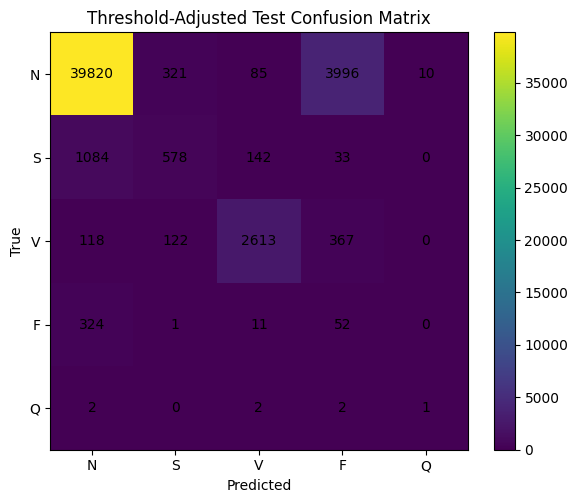

In [39]:
# ============================================================
# Search Thresholds on Validation, Apply to Test
# ============================================================

best_thr = search_thresholds_sf(val_probs, val_true)

print("Best validation macro-F1:", round(best_thr["score"], 4))
print("Best S threshold:", best_thr["s_thr"])
print("Best F threshold:", best_thr["f_thr"])

test_pred_adj = threshold_adjusted_predict(
    test_probs,
    s_thr=best_thr["s_thr"],
    f_thr=best_thr["f_thr"]
)

print("\nThreshold-adjusted test report:")
print(classification_report(
    test_true,
    test_pred_adj,
    labels=list(range(5)),
    target_names=AAMI_CLASSES,
    digits=4,
    zero_division=0
))

cm_adj = confusion_matrix(test_true, test_pred_adj, labels=list(range(5)))

plt.figure(figsize=(6, 5))
plt.imshow(cm_adj)
plt.title("Threshold-Adjusted Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(5), AAMI_CLASSES)
plt.yticks(range(5), AAMI_CLASSES)
plt.colorbar()

for i in range(5):
    for j in range(5):
        plt.text(j, i, cm_adj[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

Test Accuracy: 0.9234
Test Macro-F1: 0.4764
Test Weighted-F1: 0.9244

Test classification report:
              precision    recall  f1-score   support

           N     0.9576    0.9647    0.9611     44232
           S     0.3255    0.2705    0.2955      1837
           V     0.9481    0.8394    0.8905      3220
           F     0.0095    0.0180    0.0125       388
           Q     0.1818    0.2857    0.2222         7

    accuracy                         0.9234     49684
   macro avg     0.4845    0.4757    0.4764     49684
weighted avg     0.9261    0.9234    0.9244     49684



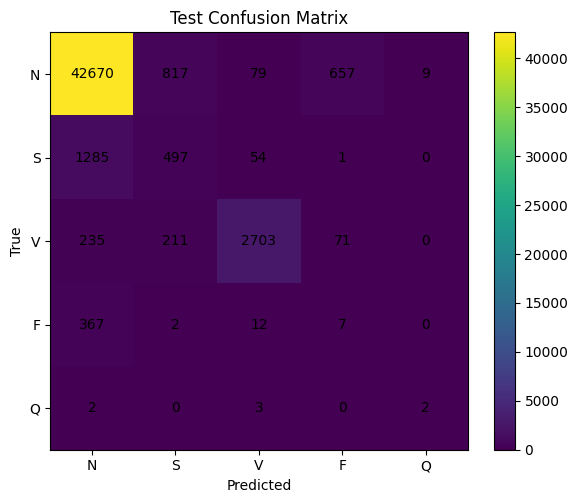

In [40]:
# ============================================================
# 11. Final Test Evaluation
# ============================================================

test_pred, test_true, test_probs, test_acc, test_macro_f1, test_weighted_f1 = eval_loader(
    model, test_loader
)

print("Test Accuracy:", round(test_acc, 4))
print("Test Macro-F1:", round(test_macro_f1, 4))
print("Test Weighted-F1:", round(test_weighted_f1, 4))

print("\nTest classification report:")
print(classification_report(
    test_true,
    test_pred,
    target_names=AAMI_CLASSES,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(test_true, test_pred, labels=list(range(5)))

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(5), AAMI_CLASSES)
plt.yticks(range(5), AAMI_CLASSES)
plt.colorbar()

for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# Multi-Class AUROC Evaluation
# ============================================================

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize labels for one-vs-rest AUROC
y_test_bin = label_binarize(test_true, classes=list(range(5)))

try:
    macro_auroc = roc_auc_score(
        y_test_bin,
        test_probs,
        average="macro",
        multi_class="ovr"
    )

    weighted_auroc = roc_auc_score(
        y_test_bin,
        test_probs,
        average="weighted",
        multi_class="ovr"
    )

    per_class_auroc = roc_auc_score(
        y_test_bin,
        test_probs,
        average=None,
        multi_class="ovr"
    )

    print("Test Macro AUROC:", round(macro_auroc, 4))
    print("Test Weighted AUROC:", round(weighted_auroc, 4))

    print("\nPer-class AUROC:")
    for cls, auc in zip(AAMI_CLASSES, per_class_auroc):
        print(f"{cls}: {auc:.4f}")

except Exception as e:
    print("Could not compute AUROC:", e)

Test Macro AUROC: 0.8899
Test Weighted AUROC: 0.924

Per-class AUROC:
N: 0.9223
S: 0.8897
V: 0.9915
F: 0.7170
Q: 0.9289


In [42]:
# ============================================================
# 12. MC Dropout Prediction
# ============================================================

def enable_mc_dropout(model):
    model.eval()

    active_layers = []

    for name, module in model.named_modules():
        if isinstance(module, nn.Dropout):
            module.train()
            active_layers.append(name)

    print("MC-active dropout layers:", active_layers)


@torch.no_grad()
def mc_dropout_predict(model, dataset, T=MC_SAMPLES, batch_size=512):
    enable_mc_dropout(model)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    all_passes = []

    for t in range(T):
        pass_probs = []

        for xb, rb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            rb = rb.to(device, non_blocking=True)

            logits = model(xb, rb)
            probs = torch.softmax(logits, dim=1)

            pass_probs.append(probs.cpu().numpy())

        pass_probs = np.concatenate(pass_probs, axis=0)
        all_passes.append(pass_probs)

    P = np.stack(all_passes, axis=0)

    mean_prob = P.mean(axis=0)
    pred = mean_prob.argmax(axis=1)
    confidence = mean_prob.max(axis=1)

    predictive_entropy = -np.sum(mean_prob * np.log(mean_prob + 1e-12), axis=1)
    expected_entropy = -np.sum(P * np.log(P + 1e-12), axis=2).mean(axis=0)
    mutual_information = predictive_entropy - expected_entropy

    return {
        "all_probs": P,
        "mean_prob": mean_prob,
        "pred": pred,
        "confidence": confidence,
        "predictive_entropy": predictive_entropy,
        "expected_entropy": expected_entropy,
        "mutual_information": mutual_information
    }


mc = mc_dropout_predict(model, test_ds, T=MC_SAMPLES)

mc_pred = mc["pred"]
mc_conf = mc["confidence"]
mc_entropy = mc["predictive_entropy"]
mc_mi = mc["mutual_information"]

print("\nMC Dropout Test Report:")
print(classification_report(
    yte,
    mc_pred,
    labels=list(range(5)),
    target_names=AAMI_CLASSES,
    digits=4,
    zero_division=0
))

MC-active dropout layers: ['cnn.0.block.3', 'cnn.1.block.3', 'cnn.2.block.3', 'lstm_drop', 'head.2']

MC Dropout Test Report:
              precision    recall  f1-score   support

           N     0.9599    0.9558    0.9578     44232
           S     0.3216    0.2531    0.2833      1837
           V     0.8933    0.8373    0.8644      3220
           F     0.0291    0.0876    0.0436       388
           Q     0.0000    0.0000    0.0000         7

    accuracy                         0.9152     49684
   macro avg     0.4408    0.4268    0.4298     49684
weighted avg     0.9246    0.9152    0.9195     49684



In [43]:
# ============================================================
# MC Dropout Multi-Class AUROC
# ============================================================

mc_mean_probs = mc["mean_prob"]

try:
    mc_macro_auroc = roc_auc_score(
        y_test_bin,
        mc_mean_probs,
        average="macro",
        multi_class="ovr"
    )

    mc_weighted_auroc = roc_auc_score(
        y_test_bin,
        mc_mean_probs,
        average="weighted",
        multi_class="ovr"
    )

    mc_per_class_auroc = roc_auc_score(
        y_test_bin,
        mc_mean_probs,
        average=None,
        multi_class="ovr"
    )

    print("MC Dropout Macro AUROC:", round(mc_macro_auroc, 4))
    print("MC Dropout Weighted AUROC:", round(mc_weighted_auroc, 4))

    print("\nMC Dropout Per-class AUROC:")
    for cls, auc in zip(AAMI_CLASSES, mc_per_class_auroc):
        print(f"{cls}: {auc:.4f}")

except Exception as e:
    print("Could not compute MC Dropout AUROC:", e)

MC Dropout Macro AUROC: 0.8844
MC Dropout Weighted AUROC: 0.9309

MC Dropout Per-class AUROC:
N: 0.9298
S: 0.9035
V: 0.9902
F: 0.6923
Q: 0.9060


ECE: 0.0165


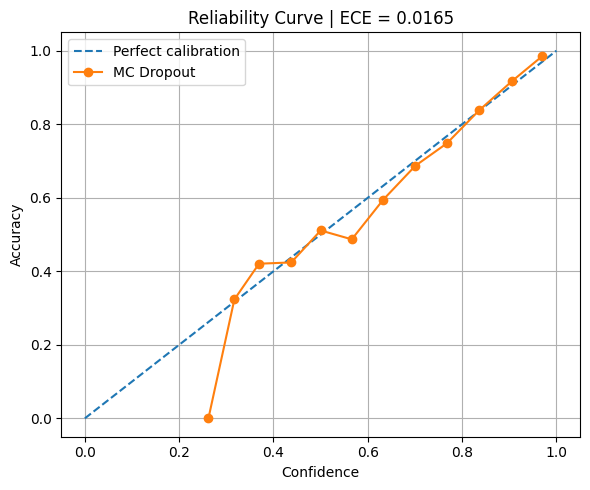

In [44]:
# ============================================================
# 13. Reliability Curve and ECE
# ============================================================

def compute_ece(y_true, pred, confidence, n_bins=15):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    bin_accs = []
    bin_confs = []
    bin_counts = []

    correct = (pred == y_true).astype(float)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (confidence > lo) & (confidence <= hi)

        if mask.sum() == 0:
            bin_accs.append(np.nan)
            bin_confs.append(np.nan)
            bin_counts.append(0)
            continue

        acc = correct[mask].mean()
        conf = confidence[mask].mean()
        count = mask.sum()

        ece += (count / len(y_true)) * abs(acc - conf)

        bin_accs.append(acc)
        bin_confs.append(conf)
        bin_counts.append(count)

    return ece, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)


ece, bin_accs, bin_confs, bin_counts = compute_ece(
    yte,
    mc_pred,
    mc_conf,
    n_bins=N_ECE_BINS
)

print("ECE:", round(ece, 4))

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(bin_confs, bin_accs, marker="o", label="MC Dropout")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability Curve | ECE = {ece:.4f}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

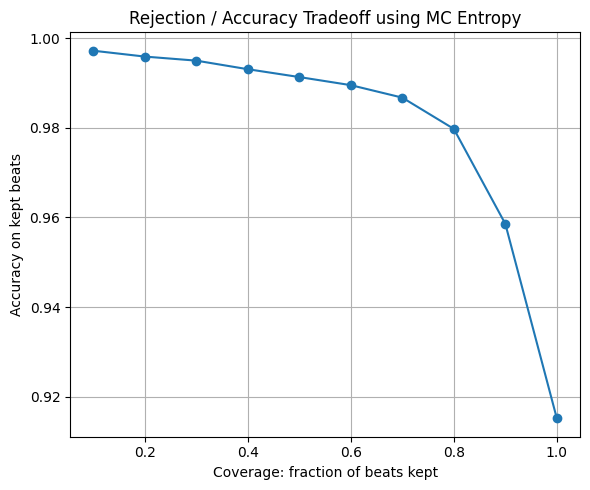

Coverage=0.1, Accuracy=0.9972
Coverage=0.2, Accuracy=0.9959
Coverage=0.3, Accuracy=0.9950
Coverage=0.4, Accuracy=0.9931
Coverage=0.5, Accuracy=0.9913
Coverage=0.6, Accuracy=0.9895
Coverage=0.7, Accuracy=0.9867
Coverage=0.8, Accuracy=0.9797
Coverage=0.9, Accuracy=0.9586
Coverage=1.0, Accuracy=0.9152


In [45]:
# ============================================================
# 14. Rejection / Accuracy Tradeoff
# ============================================================

def rejection_accuracy_curve(y_true, pred, uncertainty):
    order = np.argsort(uncertainty)  # low uncertainty first

    coverages = []
    accuracies = []

    n = len(y_true)

    for coverage in np.linspace(0.1, 1.0, 10):
        k = int(n * coverage)
        keep = order[:k]

        acc = (pred[keep] == y_true[keep]).mean()

        coverages.append(coverage)
        accuracies.append(acc)

    return np.array(coverages), np.array(accuracies)


coverages, accuracies = rejection_accuracy_curve(
    yte,
    mc_pred,
    mc_entropy
)

plt.figure(figsize=(6, 5))
plt.plot(coverages, accuracies, marker="o")
plt.xlabel("Coverage: fraction of beats kept")
plt.ylabel("Accuracy on kept beats")
plt.title("Rejection / Accuracy Tradeoff using MC Entropy")
plt.grid(True)
plt.tight_layout()
plt.show()

for c, a in zip(coverages, accuracies):
    print(f"Coverage={c:.1f}, Accuracy={a:.4f}")

Uncertainty-error AUROC using entropy: 0.8962
Uncertainty-error AUROC using mutual information: 0.9013


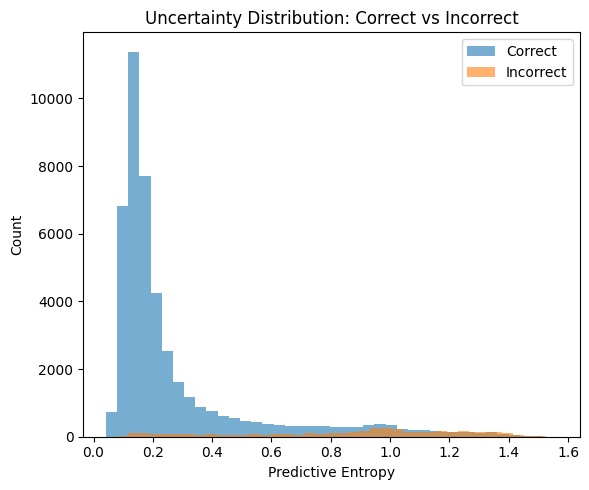

In [46]:
# ============================================================
# 15. Uncertainty vs Error
# ============================================================

correct = (mc_pred == yte).astype(int)
errors = 1 - correct

try:
    auroc_entropy = roc_auc_score(errors, mc_entropy)
    auroc_mi = roc_auc_score(errors, mc_mi)

    print("Uncertainty-error AUROC using entropy:", round(auroc_entropy, 4))
    print("Uncertainty-error AUROC using mutual information:", round(auroc_mi, 4))
except Exception as e:
    print("Could not compute uncertainty-error AUROC:", e)

plt.figure(figsize=(6, 5))
plt.hist(mc_entropy[correct == 1], bins=40, alpha=0.6, label="Correct")
plt.hist(mc_entropy[correct == 0], bins=40, alpha=0.6, label="Incorrect")
plt.xlabel("Predictive Entropy")
plt.ylabel("Count")
plt.title("Uncertainty Distribution: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# Create folder to save PPT figures
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score

FIG_DIR = "/content/ecg_ppt_figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Figures will be saved to:", FIG_DIR)

Figures will be saved to: /content/ecg_ppt_figures


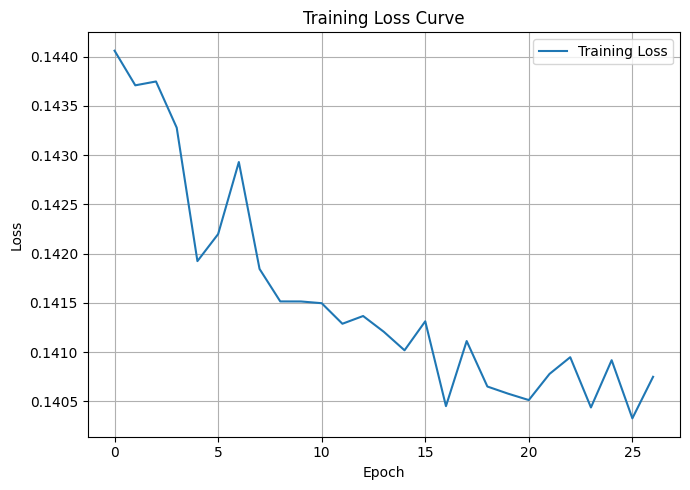

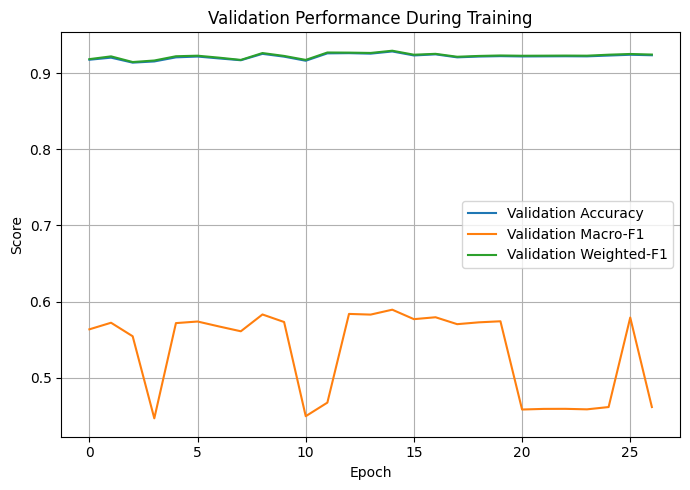

In [48]:
# ============================================================
# Plot 1: Training and Validation Curves
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(history["loss"], label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_training_loss.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.plot(history["val_macro_f1"], label="Validation Macro-F1")
plt.plot(history["val_weighted_f1"], label="Validation Weighted-F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance During Training")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_validation_metrics.png", dpi=300)
plt.show()

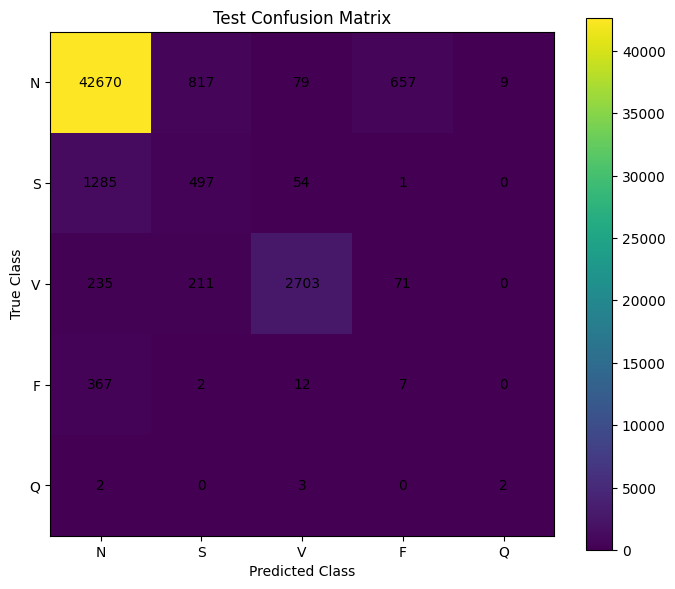

In [49]:
# ============================================================
# Plot 2: Test Confusion Matrix
# ============================================================

cm = confusion_matrix(test_true, test_pred, labels=list(range(5)))

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(range(5), AAMI_CLASSES)
plt.yticks(range(5), AAMI_CLASSES)
plt.colorbar()

for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_test_confusion_matrix.png", dpi=300)
plt.show()

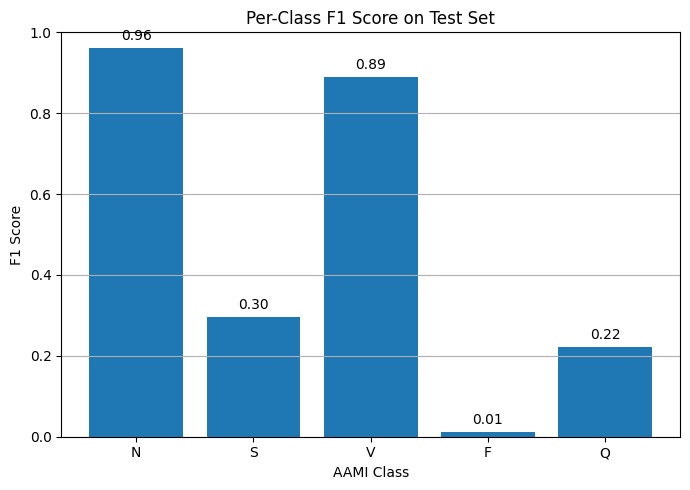

In [50]:
# ============================================================
# Plot 3: Per-Class F1 Scores
# ============================================================

report = classification_report(
    test_true,
    test_pred,
    labels=list(range(5)),
    target_names=AAMI_CLASSES,
    output_dict=True,
    zero_division=0
)

per_class_f1 = [report[c]["f1-score"] for c in AAMI_CLASSES]

plt.figure(figsize=(7, 5))
plt.bar(AAMI_CLASSES, per_class_f1)
plt.ylim(0, 1)
plt.xlabel("AAMI Class")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score on Test Set")
plt.grid(axis="y")

for i, v in enumerate(per_class_f1):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_per_class_f1.png", dpi=300)
plt.show()

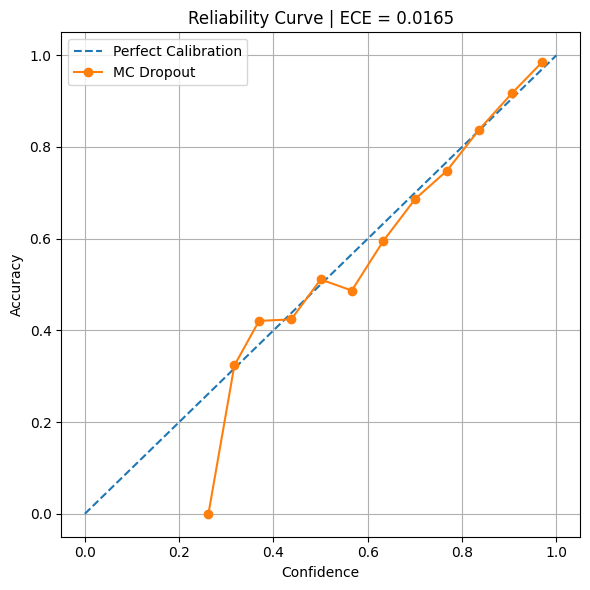

ECE: 0.0165


In [51]:
# ============================================================
# Plot 6: Reliability Curve and ECE
# ============================================================

def compute_ece(y_true, pred, confidence, n_bins=15):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    bin_accs = []
    bin_confs = []
    bin_counts = []

    correct = (pred == y_true).astype(float)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (confidence > lo) & (confidence <= hi)

        if mask.sum() == 0:
            bin_accs.append(np.nan)
            bin_confs.append(np.nan)
            bin_counts.append(0)
            continue

        acc = correct[mask].mean()
        conf = confidence[mask].mean()
        count = mask.sum()

        ece += (count / len(y_true)) * abs(acc - conf)

        bin_accs.append(acc)
        bin_confs.append(conf)
        bin_counts.append(count)

    return ece, np.array(bin_accs), np.array(bin_confs), np.array(bin_counts)


mc_pred = mc["pred"]
mc_conf = mc["confidence"]

ece, bin_accs, bin_confs, bin_counts = compute_ece(
    yte,
    mc_pred,
    mc_conf,
    n_bins=N_ECE_BINS
)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.plot(bin_confs, bin_accs, marker="o", label="MC Dropout")
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability Curve | ECE = {ece:.4f}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_reliability_curve.png", dpi=300)
plt.show()

print("ECE:", round(ece, 4))

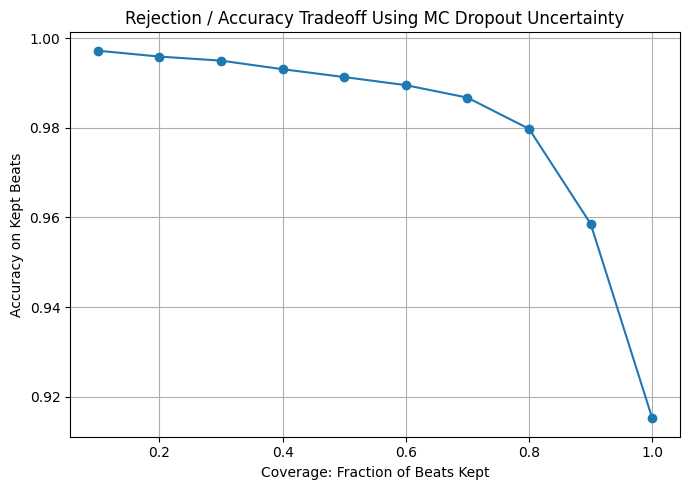

Coverage=0.1, Accuracy=0.9972
Coverage=0.2, Accuracy=0.9959
Coverage=0.3, Accuracy=0.9950
Coverage=0.4, Accuracy=0.9931
Coverage=0.5, Accuracy=0.9913
Coverage=0.6, Accuracy=0.9895
Coverage=0.7, Accuracy=0.9867
Coverage=0.8, Accuracy=0.9797
Coverage=0.9, Accuracy=0.9586
Coverage=1.0, Accuracy=0.9152


In [52]:
# ============================================================
# Plot 7: Rejection / Accuracy Tradeoff
# ============================================================

def rejection_accuracy_curve(y_true, pred, uncertainty):
    order = np.argsort(uncertainty)  # lowest uncertainty first

    coverages = []
    accuracies = []

    n = len(y_true)

    for coverage in np.linspace(0.1, 1.0, 10):
        k = int(n * coverage)
        keep = order[:k]

        acc = (pred[keep] == y_true[keep]).mean()

        coverages.append(coverage)
        accuracies.append(acc)

    return np.array(coverages), np.array(accuracies)


mc_entropy = mc["predictive_entropy"]

coverages, accuracies = rejection_accuracy_curve(
    yte,
    mc_pred,
    mc_entropy
)

plt.figure(figsize=(7, 5))
plt.plot(coverages, accuracies, marker="o")
plt.xlabel("Coverage: Fraction of Beats Kept")
plt.ylabel("Accuracy on Kept Beats")
plt.title("Rejection / Accuracy Tradeoff Using MC Dropout Uncertainty")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_rejection_accuracy_tradeoff.png", dpi=300)
plt.show()

for c, a in zip(coverages, accuracies):
    print(f"Coverage={c:.1f}, Accuracy={a:.4f}")

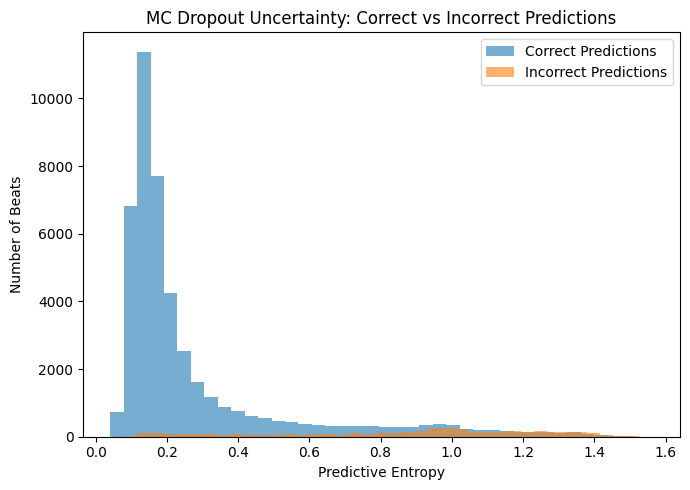

In [53]:
# ============================================================
# Plot 8: Uncertainty for Correct vs Incorrect Predictions
# ============================================================

correct = (mc_pred == yte).astype(int)

plt.figure(figsize=(7, 5))
plt.hist(mc_entropy[correct == 1], bins=40, alpha=0.6, label="Correct Predictions")
plt.hist(mc_entropy[correct == 0], bins=40, alpha=0.6, label="Incorrect Predictions")
plt.xlabel("Predictive Entropy")
plt.ylabel("Number of Beats")
plt.title("MC Dropout Uncertainty: Correct vs Incorrect Predictions")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_uncertainty_correct_vs_incorrect.png", dpi=300)
plt.show()

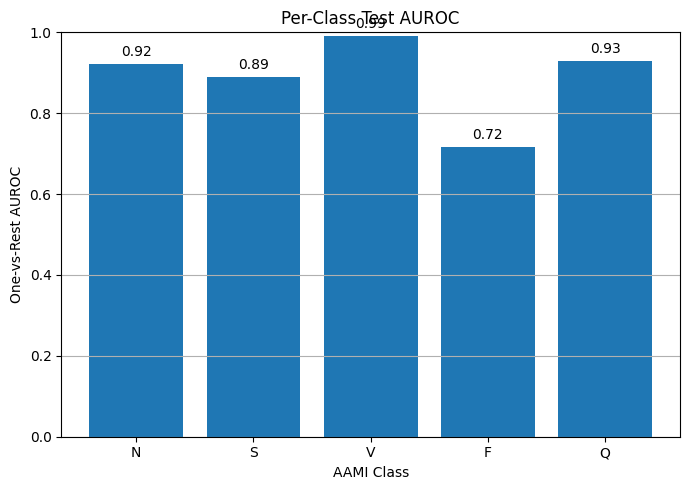

In [54]:
# ============================================================
# Plot 10: Per-Class AUROC
# Requires per_class_auroc from normal AUROC cell
# ============================================================

try:
    plt.figure(figsize=(7, 5))
    plt.bar(AAMI_CLASSES, per_class_auroc)
    plt.ylim(0, 1)
    plt.xlabel("AAMI Class")
    plt.ylabel("One-vs-Rest AUROC")
    plt.title("Per-Class Test AUROC")
    plt.grid(axis="y")

    for i, v in enumerate(per_class_auroc):
        plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/11_per_class_auroc.png", dpi=300)
    plt.show()

except NameError:
    print("Run the multi-class AUROC cell first so per_class_auroc exists.")

In [55]:
# ============================================================
# Summary Metrics for PPT
# ============================================================

base_macro = f1_score(
    test_true,
    test_pred,
    labels=list(range(5)),
    average="macro",
    zero_division=0
)

base_weighted = f1_score(
    test_true,
    test_pred,
    labels=list(range(5)),
    average="weighted",
    zero_division=0
)

base_acc = (test_true == test_pred).mean()

print("===== PPT SUMMARY: BASE MODEL =====")
print("Test Accuracy:", round(base_acc, 4))
print("Test Macro-F1:", round(base_macro, 4))
print("Test Weighted-F1:", round(base_weighted, 4))

if "test_pred_adj" in globals():
    adj_macro = f1_score(
        test_true,
        test_pred_adj,
        labels=list(range(5)),
        average="macro",
        zero_division=0
    )

    adj_weighted = f1_score(
        test_true,
        test_pred_adj,
        labels=list(range(5)),
        average="weighted",
        zero_division=0
    )

    adj_acc = (test_true == test_pred_adj).mean()

    print("\n===== PPT SUMMARY: THRESHOLD-ADJUSTED MODEL =====")
    print("Adjusted Test Accuracy:", round(adj_acc, 4))
    print("Adjusted Test Macro-F1:", round(adj_macro, 4))
    print("Adjusted Test Weighted-F1:", round(adj_weighted, 4))

if "ece" in globals():
    print("\n===== UNCERTAINTY SUMMARY =====")
    print("ECE:", round(ece, 4))

if "macro_auroc" in globals():
    print("\n===== AUROC SUMMARY =====")
    print("Macro AUROC:", round(macro_auroc, 4))
    print("Weighted AUROC:", round(weighted_auroc, 4))

===== PPT SUMMARY: BASE MODEL =====
Test Accuracy: 0.9234
Test Macro-F1: 0.4764
Test Weighted-F1: 0.9244

===== PPT SUMMARY: THRESHOLD-ADJUSTED MODEL =====
Adjusted Test Accuracy: 0.8668
Adjusted Test Macro-F1: 0.4656
Adjusted Test Weighted-F1: 0.8994

===== UNCERTAINTY SUMMARY =====
ECE: 0.0165

===== AUROC SUMMARY =====
Macro AUROC: 0.8899
Weighted AUROC: 0.924
